# Anomaly Detection — User Behaviour Classifier
**Pipeline:** EDA → feature engineering → Random Forest → submission

In [1]:
import numpy as np
import pandas as pd
import zipfile
import math
import itertools
from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, RocCurveDisplay)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42

## 1. Load Data

In [2]:
first = np.load('first_batch_with_labels.npz')
X_raw = first['X']   # [user_id, timestamp, event_type]
y_raw = first['y']   # [user_id, label]

label_map = dict(zip(y_raw[:, 0], y_raw[:, 1]))

print('X shape:', X_raw.shape)
print('y shape:', y_raw.shape)
print('Label distribution:', dict(zip(*np.unique(y_raw[:, 1], return_counts=True))))
print('Anomaly rate:', f"{y_raw[:, 1].mean():.2%}")

X shape: (167493, 3)
y shape: (1100, 2)
Label distribution: {np.int64(0): np.int64(1000), np.int64(1): np.int64(100)}
Anomaly rate: 9.09%


## 2. Split Labelled Users → anomalous.npz / normal.npz

In [3]:
anomalous_ids = {uid for uid, lbl in label_map.items() if lbl == 1}
normal_ids    = {uid for uid, lbl in label_map.items() if lbl == 0}

mask_anom = np.isin(X_raw[:, 0], list(anomalous_ids))
mask_norm = np.isin(X_raw[:, 0], list(normal_ids))

X_anom = X_raw[mask_anom]
X_norm = X_raw[mask_norm]

np.savez('anomalous.npz', X=X_anom)
np.savez('normal.npz',    X=X_norm)

print(f'anomalous.npz  ->  {X_anom.shape[0]:,} rows  ({len(anomalous_ids)} users)')
print(f'normal.npz     ->  {X_norm.shape[0]:,} rows  ({len(normal_ids)} users)')

anomalous.npz  ->  13,025 rows  (100 users)
normal.npz     ->  154,468 rows  (1000 users)


## 3. Feature Engineering

Column layout: `[user_id, timestamp, event_type]`

Key insights from EDA:
- `event_type` is **categorical** (0–5) — treat as such, not numeric
- Normal users almost never trigger types 0 & 1 (~4%); anomalous users hit them ~20% → `rare_rate` is highly discriminative
- Anomalous users show higher transition entropy (more chaotic sequences)
- Anomalous users have larger inter-event gaps on average

In [4]:
def transition_entropy(seq):
    """Shannon entropy over consecutive event-type pairs."""
    pairs = list(zip(seq[:-1], seq[1:]))
    if not pairs:
        return 0
    c = Counter(pairs)
    total = len(pairs)
    return -sum((v / total) * math.log2(v / total) for v in c.values())

def event_entropy(seq):
    """Shannon entropy over event-type marginal distribution."""
    c = Counter(seq)
    total = len(seq)
    return -sum((v / total) * math.log2(v / total) for v in c.values())

def extract_features(X: np.ndarray) -> pd.DataFrame:
    df = pd.DataFrame(X, columns=['user_id', 'timestamp', 'event_type'])
    rows = []

    for uid, grp in df.groupby('user_id'):
        grp  = grp.sort_values('timestamp')
        ts   = grp['timestamp'].values
        ev   = grp['event_type'].values
        gaps = np.diff(ts) if len(ts) > 1 else np.array([0])

        ev_counts = Counter(ev)
        ev_props  = {f'ev_prop_{i}': ev_counts.get(i, 0) / len(ev) for i in range(6)}

        row = {
            'user_id': uid,
            # Volume
            'n_events':        len(ev),
            # Timestamp / gap features
            'ts_range':        ts.max() - ts.min(),
            'gap_mean':        gaps.mean(),
            'gap_std':         gaps.std() if len(gaps) > 1 else 0,
            'gap_max':         gaps.max(),
            'gap_median':      np.median(gaps),
            'gap_cv':          gaps.std() / (gaps.mean() + 1e-9),
            # Burstiness: proportion of gaps < 2
            'burst_rate':      (gaps < 2).mean(),
            # Event-type features
            'ev_entropy':      event_entropy(ev),
            'trans_entropy':   transition_entropy(ev),
            # Rare events (types 0 & 1 almost absent in normal users)
            'rare_rate':       (ev_counts.get(0, 0) + ev_counts.get(1, 0)) / len(ev),
            # Per-type proportions
            **ev_props,
            # Longest consecutive run of same event type
            'max_run':         max((sum(1 for _ in g) for _, g in itertools.groupby(ev)), default=1),
            # Unique event type ratio
            'unique_ev_ratio': len(set(ev)) / 6,
        }
        rows.append(row)

    return pd.DataFrame(rows)


print('Extracting features...')
feats = extract_features(X_raw)
feats['label'] = feats['user_id'].map(label_map)

print('Feature matrix:', feats.shape)
feats.head()

Extracting features...
Feature matrix: (1100, 21)


,user_id,n_events,ts_range,gap_mean,gap_std,gap_max,gap_median,gap_cv,burst_rate,ev_entropy,...,rare_rate,ev_prop_0,ev_prop_1,ev_prop_2,ev_prop_3,ev_prop_4,ev_prop_5,max_run,unique_ev_ratio,label
0,2500,446,860,1.932584,1.658467,13,1.0,0.858160,0.582022,1.860525,...,0.069507,0.000000,0.069507,0.094170,0.452915,0.329596,0.053812,6,0.833333,0
1,2501,121,557,4.641667,4.757093,28,3.0,1.024867,0.225000,1.956501,...,0.033058,0.000000,0.033058,0.074380,0.190083,0.338843,0.363636,5,0.833333,0
2,2502,249,843,3.399194,2.818058,13,2.0,0.829037,0.362903,1.610876,...,0.028112,0.000000,0.028112,0.120482,0.554217,0.277108,0.020080,8,0.833333,0
3,2503,100,932,9.414141,11.853491,85,5.0,1.259115,0.232323,1.943800,...,0.020000,0.010000,0.010000,0.130000,0.270000,0.440000,0.140000,6,1.000000,0
4,2504,46,629,13.977778,14.753514,72,8.0,1.055498,0.111111,2.478384,...,0.260870,0.086957,0.173913,0.195652,0.195652,0.260870,0.086957,4,1.000000,0


## 4. Train Random Forest Classifier

In [5]:
feature_cols = [c for c in feats.columns if c not in ('user_id', 'label')]

X_train = feats[feature_cols].values
y_train = feats['label'].values

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y_pred_cv  = cross_val_predict(model, X_train, y_train, cv=cv)
y_proba_cv = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

print('=== 5-Fold CV Results ===')
print(classification_report(y_train, y_pred_cv, target_names=['Normal', 'Anomalous']))
print(f'AUC-ROC: {roc_auc_score(y_train, y_proba_cv):.4f}')

=== 5-Fold CV Results ===
              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97      1000
   Anomalous       0.83      0.53      0.65       100

    accuracy                           0.95      1100
   macro avg       0.89      0.76      0.81      1100
weighted avg       0.94      0.95      0.94      1100

AUC-ROC: 0.9377


=== 5-Fold CV Results ===
Stats:   n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1

              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97      1000
   Anomalous       0.83      0.53      0.65       100

    accuracy                           0.95      1100
   macro avg       0.89      0.76      0.81      1100
weighted avg       0.94      0.95      0.94      1100

AUC-ROC: 0.9377

In [10]:
# Fit final model on all labelled data
model.fit(X_train, y_train)
print('Final model trained on', X_train.shape[0], 'users.')

Final model trained on 1100 users.


## 5. Visualisations

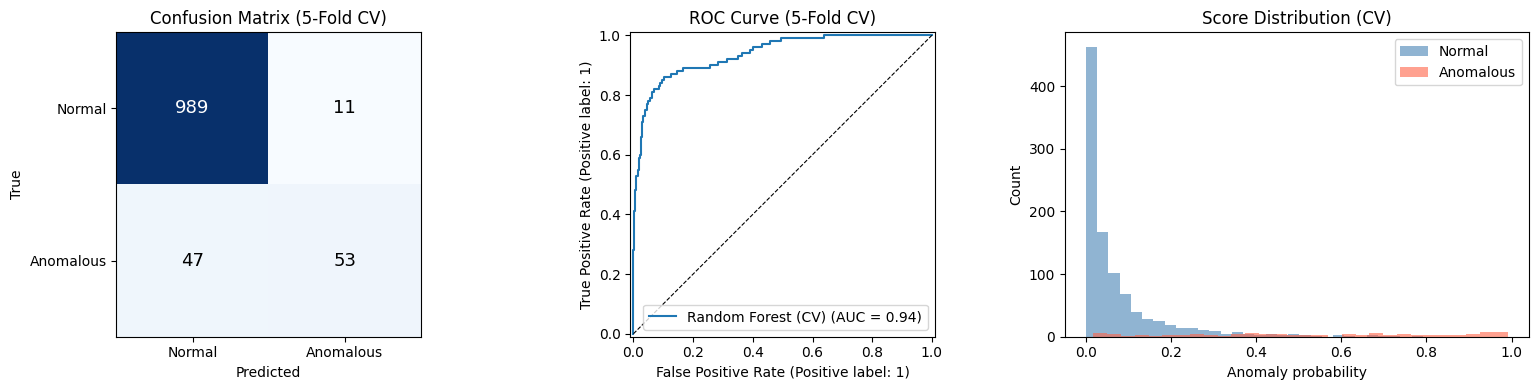

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix
cm = confusion_matrix(y_train, y_pred_cv)
axes[0].imshow(cm, cmap='Blues')
for (r, c), v in np.ndenumerate(cm):
    axes[0].text(c, r, v, ha='center', va='center', fontsize=13,
                 color='white' if v > cm.max() / 2 else 'black')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Normal', 'Anomalous'])
axes[0].set_yticklabels(['Normal', 'Anomalous'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (5-Fold CV)')

# ROC curve
RocCurveDisplay.from_predictions(y_train, y_proba_cv, ax=axes[1], name='Random Forest (CV)')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[1].set_title('ROC Curve (5-Fold CV)')

# Score distribution
axes[2].hist(y_proba_cv[y_train == 0], bins=30, alpha=0.6, label='Normal',    color='steelblue')
axes[2].hist(y_proba_cv[y_train == 1], bins=30, alpha=0.6, label='Anomalous', color='tomato')
axes[2].set_xlabel('Anomaly probability')
axes[2].set_ylabel('Count')
axes[2].set_title('Score Distribution (CV)')
axes[2].legend()

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150)
plt.show()

## 6. Feature Importances

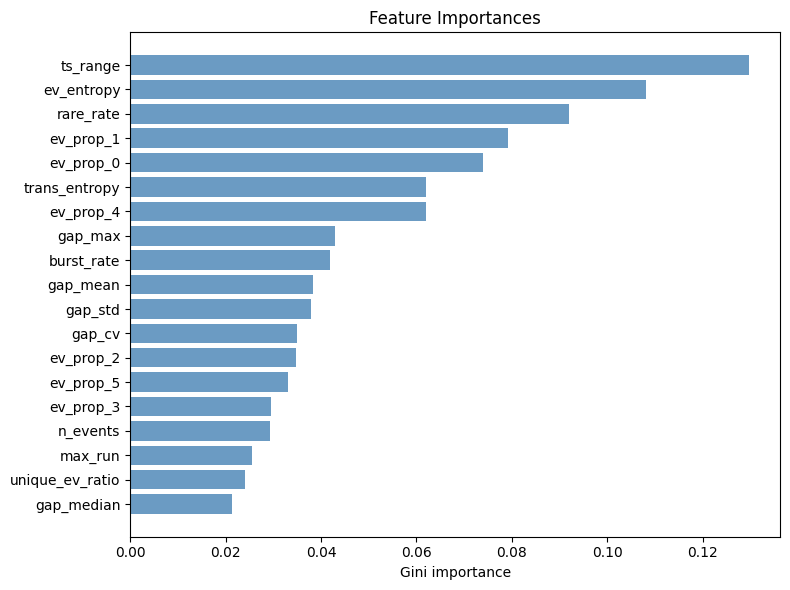

In [8]:
fi_df = pd.DataFrame({'feature': feature_cols,
                       'importance': model.feature_importances_})
fi_df = fi_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_df['feature'], fi_df['importance'], color='steelblue', alpha=0.8)
ax.set_xlabel('Gini importance')
ax.set_title('Feature Importances')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150)
plt.show()

## 7. Predict on Second Batch & Save Submission

In [9]:
second = np.load('second_batch.npz')
key2   = 'X' if 'X' in second else list(second.keys())[0]
X2_raw = second[key2]
print('Second batch shape:', X2_raw.shape)

feats2 = extract_features(X2_raw)
X2     = feats2[feature_cols].values
proba2 = model.predict_proba(X2)[:, 1]

# Normalise to [0, 1]
y_score_norm = (proba2 - proba2.min()) / (proba2.max() - proba2.min())

# Save submission
np.savez('submission.npz', predictions=y_score_norm)
with zipfile.ZipFile('submission.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write('submission.npz', arcname='submission.npz')
pd.DataFrame({'predictions': y_score_norm}).to_csv('submission.csv', index=False)

print(f'Users predicted : {feats2["user_id"].nunique()}')
print(f'First 5 user IDs: {feats2["user_id"].values[:5]}')
print(f'Score range     : [{y_score_norm.min():.4f}, {y_score_norm.max():.4f}]')
print('submission.zip ready for Codabench')

Second batch shape: (134594, 3)
Users predicted : 860
First 5 user IDs: [4100 4101 4102 4103 4104]
Score range     : [0.0000, 1.0000]
submission.zip ready for Codabench


Reference labels loaded: 860 users
Submission loaded: 860 predictions

─── Scores ───────────────────────────────
AUC:       0.6716
Precision: 0.3913
Recall:    0.1500
F1 Score:  0.2169
──────────────────────────────────────────
scores.json written successfully.

This ver:
Submission loaded: 860 predictions

─── Scores ───────────────────────────────
AUC: 0.6700
Precision: 0.4286
Recall: 0.1500
F1 Score: 0.2222
──────────────────────────────────────────
scores.json written successfully.